## Hermes SPAD Position Optimization Sweep

Connects to the running qudi instance and performs a **two-phase** position optimization
using `hermes_optimize_logic`:

1. **Z sweep** — find the optimal focus by sweeping Z and tracking the 9 brightest
   pixels (one per emitter in the 3×3 array).  The scanner is then moved to the
   peak-Z position.
2. **XY sweep** — at the optimal Z, sweep XY to find the lateral signal maximum.

**Prerequisites:**
- qudi is running with `hermes_optimize_logic`, `hermes_probe_logic`, and `camera_Hermes` activated
- The Hermes camera live view is **stopped** (snap mode requires it)
- Optimizer settings (scan range, resolution) are configured in `scanner_spad_gui`
- The scanner is positioned at the approximate centre of the region of interest

In [6]:
import time
import numpy as np
import matplotlib.pyplot as plt

opt       = hermes_optimize_logic
spad      = hermes_probe_logic
cam       = camera_Hermes
cam_logic = camera_hermes_logic

print(f'Scanner position : {dict(spad.scanner_target)}')
print(f'Optimizer running: {opt.optimizer_running}')

Scanner position : {'x': 0.0001371649, 'y': 7.35443e-05, 'z': 0.0001379442}
Optimizer running: False


## Inspect / override optimizer settings

The sweep uses the optimizer settings already configured in `scanner_spad_gui`.
Inspect or optionally override range and resolution before running.

In [7]:
print('Scan sequence  :', opt.scan_sequence)
print('Scan range     :', {k: f'{v*1e6:.2f} µm' for k, v in opt.scan_range.items()})
print('Num points     :', opt.scan_resolution)
print('NFrames        :', cam._NFrames, ' (frames averaged per position)')
exposure_ms = float(cam.get_exposure()) * 1e3
print('Exposure       :', f'{exposure_ms:.2f} ms' if exposure_ms is not None else '<unavailable>')

# --- Optional: override optimizer settings from notebook ---
# opt.set_optimize_settings(
#     scan_sequence=(('x', 'y'), ('z',)),
#     scan_dimension=[2, 1],
#     range={'x': 10e-6, 'y': 10e-6, 'z': 5e-6},
#     resolution={'x': 20, 'y': 20, 'z': 15},
# )

Scan sequence  : (('x', 'y'),)
Scan range     : {'x': '0.50 µm', 'y': '0.40 µm', 'z': '5.00 µm'}
Num points     : {'x': 12, 'y': 10, 'z': 120}
NFrames        : 5  (frames averaged per position)
Exposure       : 52.00 ms


## Optimization helpers

Signal metric, peak finder, and axis utilities used by `run_optimize_sweep()`.

In [8]:
def _moving_avg(y, w):
    w = max(1, int(w))
    if w % 2 == 0:
        w += 1
    if w == 1:
        return y.astype(float)
    pad = w // 2
    return np.convolve(
        np.pad(y.astype(float), pad, mode='edge'),
        np.ones(w) / w,
        mode='valid'
    )


def _peak_z_um(z_um, y):
    """Robust Z-peak finder: smoothed argmax + local quadratic fit."""
    z, y = np.asarray(z_um, float), np.asarray(y, float)
    if z.size < 3:
        return float(z[np.argmax(y)])
    w = max(5, min(21, round(0.07 * z.size)))
    if w % 2 == 0:
        w += 1
    ys = _moving_avg(y, w)
    ci = int(np.argmax(ys))
    i0, i1 = max(0, ci - 6), min(z.size - 1, ci + 6)
    if i1 - i0 < 2:
        return float(z[ci])
    p2, p1, _ = np.polyfit(z[i0:i1 + 1], y[i0:i1 + 1], 2)
    if np.isfinite(p2) and p2 < 0:
        return float(np.clip(-p1 / (2 * p2), z[i0], z[i1]))
    return float(z[ci])


def _bright9(frames_nhw):
    """Sum of 9 brightest pixels per frame.  frames_nhw: (N, H, W) -> (N,)"""
    flat = frames_nhw.reshape(frames_nhw.shape[0], -1)
    k = min(9, flat.shape[1])
    return np.partition(flat, -k, axis=1)[:, -k:].sum(axis=1)


def _axis_key(pos_dict, name):
    return next(k for k in pos_dict if str(k).lower() == name.lower())

## `run_optimize_sweep()`

Runs the full Z→XY optimization in one call: sweeps, plots, and moves scanner to peak.
Accepts an optional `iteration` label for plot titles when called in a loop.

In [9]:
def run_optimize_sweep(iteration=None):
    """Run Z then XY optimization sweep, plot results, and move scanner to peak."""
    tag = f'iter {iteration}' if iteration is not None else ''

    # -- Z sweep --------------------------------------------------------
    opt.scan_sequence = (('z',),)
    opt.optimizer_sequence_dimensions = (1,)
    opt.start_optimize()
    t0 = time.time()
    while opt.optimizer_running:
        time.sleep(0.5)
    print(f'    Z sweep complete in {time.time() - t0:.0f}s')

    z_data    = opt.spad_scan_data
    z_ax      = tuple(z_data[0]['axes'])[0]
    z_um      = np.array(z_data[0]['grids'][z_ax]) * 1e6
    frames_z  = np.array(z_data[0]['frames'])            # (Nz, H, W)
    signal_z  = _bright9(frames_z)
    z_peak_um = _peak_z_um(z_um, signal_z)

    w = max(5, min(21, round(0.07 * z_um.size)))
    if w % 2 == 0:
        w += 1
    ys = _moving_avg(signal_z, w)
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.plot(z_um, signal_z, 'o', ms=3, alpha=0.6, label='data')
    ax.plot(z_um, ys, '-', lw=2, label=f'smoothed (MA w={w})')
    ax.axvline(z_peak_um, color='r', ls='--', lw=1.5,
               label=f'peak {z_peak_um:.3f} µm')
    ax.set_xlabel('Z (µm)')
    ax.set_ylabel('9-brightest sum (counts)')
    ax.set_title(f'Z sweep{"—" + tag if tag else ""}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    pos = dict(spad.scanner_target)
    pos[_axis_key(pos, 'z')] = z_peak_um * 1e-6
    spad.set_target_position(pos, move_blocking=True)
    print(f'    Z -> {z_peak_um:.3f} um')

    # -- XY sweep -------------------------------------------------------
    opt.scan_sequence = (('x', 'y'),)
    opt.optimizer_sequence_dimensions = (2,)
    opt.start_optimize()
    t0 = time.time()
    while opt.optimizer_running:
        time.sleep(0.5)
    print(f'    XY sweep complete in {time.time() - t0:.0f}s')

    xy_data   = opt.spad_scan_data
    ax0, ax1  = tuple(xy_data[0]['axes'])
    g0 = np.array(xy_data[0]['grids'][ax0]) * 1e6
    g1 = np.array(xy_data[0]['grids'][ax1]) * 1e6
    frames_xy = np.array(xy_data[0]['frames'])           # (Nx, Ny, H, W)
    nx, ny    = len(g0), len(g1)

    flat_frames = frames_xy.reshape(nx * ny, *frames_xy.shape[2:])
    metric      = _bright9(flat_frames).reshape(nx, ny)
    pi, pj      = np.unravel_index(np.nanargmax(metric), metric.shape)

    fig, ax = plt.subplots(figsize=(5, 4))
    extent = [g0[0], g0[-1], g1[0], g1[-1]]
    ax.imshow(metric.T, origin='lower', aspect='auto', extent=extent, cmap='inferno')
    ax.plot(g0[pi], g1[pj], 'w+', ms=12, mew=2,
            label=f'peak ({g0[pi]:.3f}, {g1[pj]:.3f}) µm')
    ax.set_xlabel(f'{ax0} (µm)')
    ax.set_ylabel(f'{ax1} (µm)')
    ax.set_title(f'XY sweep{"—" + tag if tag else ""}')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

    pos = dict(spad.scanner_target)
    pos[_axis_key(pos, ax0)] = float(g0[pi]) * 1e-6
    pos[_axis_key(pos, ax1)] = float(g1[pj]) * 1e-6
    spad.set_target_position(pos, move_blocking=True)
    print(f'    XY -> ({g0[pi]:.3f}, {g1[pj]:.3f}) um')

    # -- Averaged frame at optimized position ---------------------------
    opt_frame = frames_xy[pi, pj].copy()
    fig_f, ax_f = plt.subplots(figsize=(5, 4))
    im_f = ax_f.imshow(opt_frame, origin='lower', cmap='inferno')
    _title = (
        f'Averaged frame at optimized position\n'
        f'{ax0}={g0[pi]:.3f} µm, {ax1}={g1[pj]:.3f} µm'
        + (f'  —  {tag}' if tag else '')
    )
    ax_f.set_title(_title)
    ax_f.set_xlabel('pixel column')
    ax_f.set_ylabel('pixel row')
    fig_f.colorbar(im_f, ax=ax_f, label='counts')
    plt.tight_layout()
    plt.show()

    final = {k: f'{v * 1e6:.3f} um' for k, v in dict(spad.scanner_target).items()}
    print(f'    Final position: {final}')

## Run optimization

Execute the Z→XY sweep and move scanner to the optimal position.

    Z sweep complete in 58s


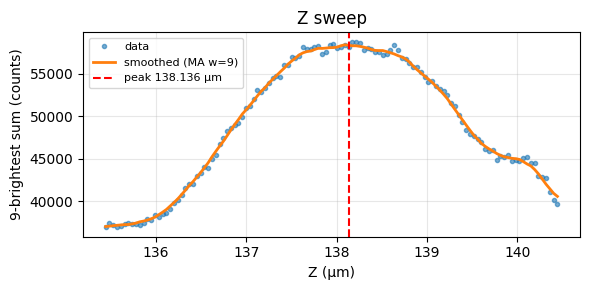

    Z -> 138.136 um
    XY sweep complete in 59s


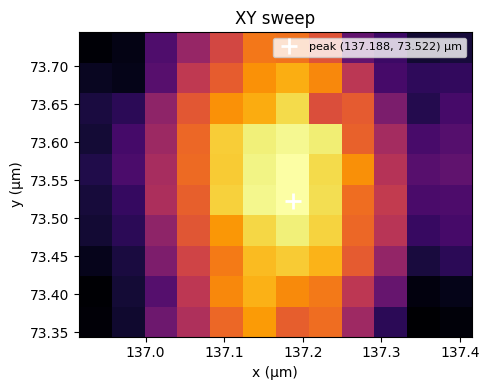

    XY -> (137.188, 73.522) um


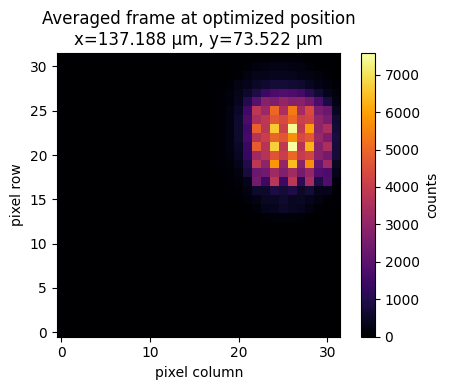

    Final position: {'x': '137.188 um', 'y': '73.522 um', 'z': '138.136 um'}


In [10]:
run_optimize_sweep()